In [1]:
import time
import pyreadr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, KFold
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

#carga de datos
result = pyreadr.read_r('data/listings.RData')
df = result['listings']

print("Shape inicial:", df.shape)
df.head()

Shape inicial: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


Punto 1

In [2]:
# Limpiar price
df["price"] = df["price"].astype(str).str.replace("$", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Eliminar SOLO NaN de price
df = df.dropna(subset=["price"]).copy()

print("Después de limpiar price:", df.shape)
print(df["price"].describe())

Después de limpiar price: (76246, 80)
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64


In [3]:
# Seleccionar variables numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"]).copy()

# Asegurar que price esté incluida
if "price" not in df_numeric.columns:
    df_numeric["price"] = df["price"]

print("Columnas numéricas:", len(df_numeric.columns))
print(df_numeric.columns.tolist())

Columnas numéricas: 16
['id', 'scrape_id', 'latitude', 'longitude', 'bathrooms', 'price', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month']


In [4]:
#  Variables numéricas
X = df_numeric.drop(columns=["price"]).copy()

# Evitar fuga de información
if "log_price" in X.columns:
    X = X.drop(columns=["log_price"])

# Eliminar columnas completamente vacías
X = X.dropna(axis=1, how="all")

# Rellenar NaN restantes
X = X.fillna(X.mean(numeric_only=True))

y = df_numeric["price"].copy()

print("Shape X:", X.shape)
print("NaN totales en X:", X.isna().sum().sum())

Shape X: (76246, 15)
NaN totales en X: 0


In [5]:
#normalizacion 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar forma
print("Shape X_scaled:", X_scaled.shape)

Shape X_scaled: (76246, 15)


In [6]:
# Definir conjuntos
indices = np.arange(len(X))

train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42
)

X_train_reg = X.iloc[train_idx]
X_test_reg = X.iloc[test_idx]
y_train_reg = y.iloc[train_idx]
y_test_reg = y.iloc[test_idx]

print("Train:", X_train_reg.shape, "Test:", X_test_reg.shape)

Train: (60996, 15) Test: (15250, 15)


In [7]:
pipe_knn_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

pipe_knn_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = pipe_knn_reg.predict(X_test_reg)

In [8]:
rmse_knn = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae_knn = mean_absolute_error(y_test_reg, y_pred_reg)
r2_knn = r2_score(y_test_reg, y_pred_reg)

print("RMSE:", rmse_knn)
print("MAE:", mae_knn)
print("R2:", r2_knn)

RMSE: 3552.7278785412113
MAE: 631.9491672131148
R2: 0.3224597246122477


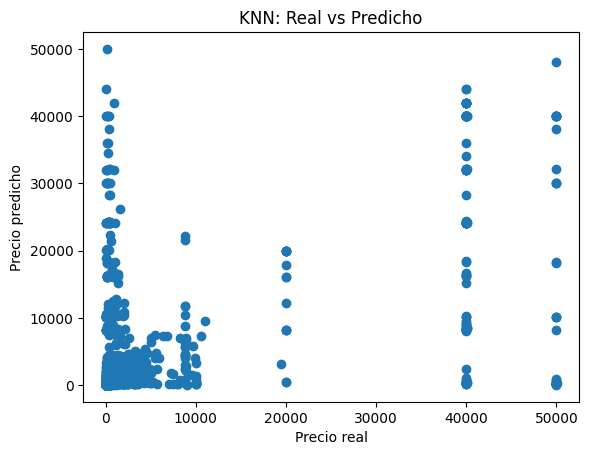

In [9]:
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("KNN: Real vs Predicho")
plt.show()

## Punto 3. Comparación del modelo KNN con modelos anteriores

In [10]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión lineal",
        "Árbol de regresión (depth=10)",
        "Naive Bayes",
        "KNN"
    ],
    "RMSE": [
        4297.59,
        37.43,
        4347.22,
        rmse_knn
    ],
    "MAE": [
        np.nan,
        np.nan,
        664.50,
        mae_knn
    ],
    "R2": [
        np.nan,
        np.nan,
        -0.0145,
        r2_knn
    ]
})

comparacion_modelos = comparacion_modelos.sort_values("RMSE").reset_index(drop=True)
comparacion_modelos["Ranking_RMSE"] = comparacion_modelos["RMSE"].rank(method="dense")

print("Tabla comparativa de modelos de regresión:")
display(comparacion_modelos)

mejor_modelo = comparacion_modelos.iloc[0]
print(f"\nEl modelo con mejor desempeño según RMSE fue: {mejor_modelo['Modelo']} ({mejor_modelo['RMSE']:.2f})")

Tabla comparativa de modelos de regresión:


,Modelo,RMSE,MAE,R2,Ranking_RMSE
0,Árbol de regresión (depth=10),37.430000,NaN,NaN,1.0
1,KNN,3552.727879,631.949167,0.32246,2.0
2,Regresión lineal,4297.590000,NaN,NaN,3.0
3,Naive Bayes,4347.220000,664.500000,-0.01450,4.0



El modelo con mejor desempeño según RMSE fue: Árbol de regresión (depth=10) (37.43)


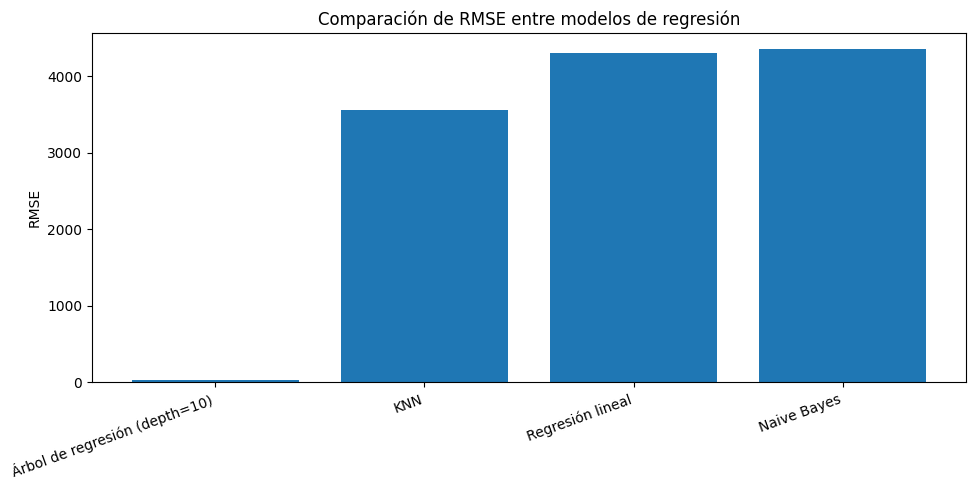

In [11]:
tabla_plot = comparacion_modelos.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10,5))
plt.bar(tabla_plot["Modelo"], tabla_plot["RMSE"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("RMSE")
plt.title("Comparación de RMSE entre modelos de regresión")
plt.tight_layout()
plt.show()

Punto 4: modelo de clasificación

In [12]:
#variable categorica 
q1 = y.quantile(1/3)
q2 = y.quantile(2/3)

y_class = pd.cut(
    y,
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True
)

limites_clases = pd.DataFrame({
    "Categoría": ["barata", "media", "cara"],
    "Rango": [
        f"price <= {q1:.2f}",
        f"{q1:.2f} < price <= {q2:.2f}",
        f"price > {q2:.2f}"
    ]
})

print("Límites de las categorías:")
display(limites_clases)
print(y_class.value_counts())

Límites de las categorías:


,Categoría,Rango
0,barata,price <= 143.00
1,media,143.00 < price <= 268.00
2,cara,price > 268.00


price
barata    25689
cara      25404
media     25153
Name: count, dtype: int64


In [13]:
X_train_class = X.iloc[train_idx]
X_test_class = X.iloc[test_idx]
y_train_class = y_class.iloc[train_idx]
y_test_class = y_class.iloc[test_idx]

pipe_knn_class = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipe_knn_class.fit(X_train_class, y_train_class)
y_pred_class = pipe_knn_class.predict(X_test_class)

## Punto 5. Evaluación con conjunto de prueba

### Eficiencia del algoritmo para predecir y clasificar

In [14]:
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test_class, y_pred_class, average="macro", zero_division=0
)

metricas_knn_test = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "R²", "Accuracy", "Precision macro", "Recall macro", "F1 macro"],
    "Valor": [
        rmse_knn,
        mae_knn,
        r2_knn,
        accuracy_score(y_test_class, y_pred_class),
        precision_macro,
        recall_macro,
        f1_macro
    ]
})

print("Métricas del modelo KNN en el conjunto de prueba:")
display(metricas_knn_test)

Métricas del modelo KNN en el conjunto de prueba:


,Métrica,Valor
0,RMSE,3552.727879
1,MAE,631.949167
2,R²,0.322460
3,Accuracy,0.623279
4,Precision macro,0.618090
5,Recall macro,0.623780
6,F1 macro,0.618589


In [15]:
print("Reporte de clasificación:")
display(pd.DataFrame(classification_report(
    y_test_class,
    y_pred_class,
    output_dict=True,
    zero_division=0
)).transpose())

Reporte de clasificación:


,precision,recall,f1-score,support
barata,0.631363,0.726844,0.675747,5085.000000
cara,0.691387,0.697684,0.694521,5051.000000
media,0.531519,0.446813,0.485499,5114.000000
accuracy,0.623279,0.623279,0.623279,0.623279
macro avg,0.618090,0.623780,0.618589,15250.000000
weighted avg,0.617762,0.623279,0.618167,15250.000000


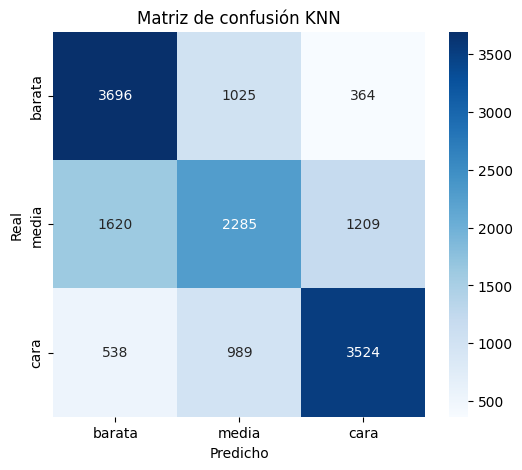

In [16]:
#matriz de confusión para KNN con categorías de precio
orden_clases = ["barata", "media", "cara"]
cm = confusion_matrix(y_test_class, y_pred_class, labels=orden_clases)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=orden_clases, yticklabels=orden_clases)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión KNN")
plt.show()

## Punto 7. Análisis de sobreajuste

In [17]:
train_acc = accuracy_score(y_train_class, pipe_knn_class.predict(X_train_class))
test_acc = accuracy_score(y_test_class, y_pred_class)

analisis_sobreajuste = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Accuracy": [train_acc, test_acc]
})

display(analisis_sobreajuste)
print("Diferencia de accuracy:", round(train_acc - test_acc, 4))

,Conjunto,Accuracy
0,Entrenamiento,0.735802
1,Prueba,0.623279


Diferencia de accuracy: 0.1125


## Punto 8. Modelo usando validación cruzada

In [18]:
cv_class = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(
    pipe_knn_class,
    X,
    y_class,
    cv=cv_class,
    scoring="accuracy",
    n_jobs=-1
)

cv_f1 = cross_val_score(
    pipe_knn_class,
    X,
    y_class,
    cv=cv_class,
    scoring="f1_macro",
    n_jobs=-1
)

resultados_cv = pd.DataFrame({
    "Métrica": ["Accuracy CV promedio", "Accuracy CV std", "F1 macro CV promedio", "F1 macro CV std", "Accuracy prueba modelo base"],
    "Valor": [
        cv_accuracy.mean(),
        cv_accuracy.std(),
        cv_f1.mean(),
        cv_f1.std(),
        accuracy_score(y_test_class, y_pred_class)
    ]
})

display(resultados_cv)

,Métrica,Valor
0,Accuracy CV promedio,0.617855
1,Accuracy CV std,0.000775
2,F1 macro CV promedio,0.612123
3,F1 macro CV std,0.000981
4,Accuracy prueba modelo base,0.623279


## Punto 9. Tuneo de hiperparámetros

In [19]:
pipe_knn_reg_tune = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

param_grid_reg = {
    "knn__n_neighbors": [3, 5, 9],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

cv_reg = KFold(n_splits=3, shuffle=True, random_state=42)

grid_reg = GridSearchCV(
    pipe_knn_reg_tune,
    param_grid_reg,
    cv=cv_reg,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_reg.fit(X_train_reg, y_train_reg)

best_knn_reg = grid_reg.best_estimator_
y_pred_reg_tuned = best_knn_reg.predict(X_test_reg)

rmse_knn_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_tuned))
mae_knn_tuned = mean_absolute_error(y_test_reg, y_pred_reg_tuned)
r2_knn_tuned = r2_score(y_test_reg, y_pred_reg_tuned)

print("Mejores parámetros regresión:", grid_reg.best_params_)

comparacion_tuneo_reg = pd.DataFrame({
    "Modelo": ["KNN base", "KNN tuneado"],
    "RMSE": [rmse_knn, rmse_knn_tuned],
    "MAE": [mae_knn, mae_knn_tuned],
    "R2": [r2_knn, r2_knn_tuned]
})

display(comparacion_tuneo_reg)

Mejores parámetros regresión: {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'}


,Modelo,RMSE,MAE,R2
0,KNN base,3552.727879,631.949167,0.322460
1,KNN tuneado,3231.901419,576.760698,0.439304


In [20]:
pipe_knn_class_tune = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_class = {
    "knn__n_neighbors": [3, 5, 9],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

grid_class = GridSearchCV(
    pipe_knn_class_tune,
    param_grid_class,
    cv=cv_class,
    scoring="f1_macro",
    n_jobs=-1
)

grid_class.fit(X_train_class, y_train_class)

best_knn_class = grid_class.best_estimator_
y_pred_class_tuned = best_knn_class.predict(X_test_class)

precision_macro_tuned, recall_macro_tuned, f1_macro_tuned, _ = precision_recall_fscore_support(
    y_test_class, y_pred_class_tuned, average="macro", zero_division=0
)

print("Mejores parámetros clasificación:", grid_class.best_params_)

comparacion_tuneo_class = pd.DataFrame({
    "Modelo": ["KNN base", "KNN tuneado"],
    "Accuracy": [
        accuracy_score(y_test_class, y_pred_class),
        accuracy_score(y_test_class, y_pred_class_tuned)
    ],
    "Precision macro": [precision_macro, precision_macro_tuned],
    "Recall macro": [recall_macro, recall_macro_tuned],
    "F1 macro": [f1_macro, f1_macro_tuned]
})

display(comparacion_tuneo_class)

Mejores parámetros clasificación: {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'}


,Modelo,Accuracy,Precision macro,Recall macro,F1 macro
0,KNN base,0.623279,0.618090,0.623780,0.618589
1,KNN tuneado,0.651934,0.650941,0.652304,0.651492


In [21]:
resultados_grid_reg = pd.DataFrame(grid_reg.cv_results_)[
    ["param_knn__n_neighbors", "param_knn__weights", "param_knn__p", "mean_test_score", "rank_test_score"]
].sort_values("rank_test_score")

resultados_grid_reg["RMSE_promedio_cv"] = -resultados_grid_reg["mean_test_score"]
display(resultados_grid_reg.drop(columns=["mean_test_score"]).head(10))

resultados_grid_class = pd.DataFrame(grid_class.cv_results_)[
    ["param_knn__n_neighbors", "param_knn__weights", "param_knn__p", "mean_test_score", "rank_test_score"]
].sort_values("rank_test_score")

resultados_grid_class["F1_macro_promedio_cv"] = resultados_grid_class["mean_test_score"]
display(resultados_grid_class.drop(columns=["mean_test_score"]).head(10))

,param_knn__n_neighbors,param_knn__weights,param_knn__p,rank_test_score,RMSE_promedio_cv
9,9,distance,1,1,3357.165786
11,9,distance,2,2,3388.819543
5,5,distance,1,3,3474.891831
7,5,distance,2,4,3489.354726
1,3,distance,1,5,3567.256434
3,3,distance,2,6,3575.624476
0,3,uniform,1,7,3688.997186
2,3,uniform,2,8,3693.707958
4,5,uniform,1,9,3720.443378
6,5,uniform,2,10,3729.509593


,param_knn__n_neighbors,param_knn__weights,param_knn__p,rank_test_score,F1_macro_promedio_cv
9,9,distance,1,1,0.638345
5,5,distance,1,2,0.627867
11,9,distance,2,3,0.627422
8,9,uniform,1,4,0.626982
7,5,distance,2,5,0.618781
4,5,uniform,1,6,0.616415
10,9,uniform,2,7,0.615382
1,3,distance,1,8,0.612882
0,3,uniform,1,9,0.608410
6,5,uniform,2,10,0.606627


## Punto 10. Comparación con árbol de decisión, random forest y naive bayes

In [22]:
modelos_clasificacion = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", KNeighborsClassifier(
            n_neighbors=grid_class.best_params_["knn__n_neighbors"],
            weights=grid_class.best_params_["knn__weights"],
            p=grid_class.best_params_["knn__p"]
        ))
    ]),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Naive Bayes": GaussianNB()
}

comparacion_clasificacion = []

for nombre, modelo in modelos_clasificacion.items():
    inicio = time.time()
    modelo.fit(X_train_class, y_train_class)
    y_pred_tmp = modelo.predict(X_test_class)
    fin = time.time()

    p_tmp, r_tmp, f_tmp, _ = precision_recall_fscore_support(
        y_test_class, y_pred_tmp, average="macro", zero_division=0
    )

    comparacion_clasificacion.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test_class, y_pred_tmp),
        "Precision macro": p_tmp,
        "Recall macro": r_tmp,
        "F1 macro": f_tmp,
        "Tiempo total (s)": fin - inicio
    })

comparacion_clasificacion = pd.DataFrame(comparacion_clasificacion)
comparacion_clasificacion = comparacion_clasificacion.sort_values(
    by=["F1 macro", "Accuracy"], ascending=False
).reset_index(drop=True)

display(comparacion_clasificacion)
print("Mejor modelo de clasificación:", comparacion_clasificacion.loc[0, "Modelo"])
print("Modelo más lento:", comparacion_clasificacion.sort_values("Tiempo total (s)", ascending=False).iloc[0]["Modelo"])

,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,Tiempo total (s)
0,Random Forest,0.728131,0.726216,0.728510,0.726532,2.110083
1,Árbol de decisión,0.669770,0.668774,0.670134,0.668117,0.369410
2,KNN,0.651934,0.650941,0.652304,0.651492,8.195885
3,Naive Bayes,0.342820,0.343072,0.342647,0.341881,0.066944


Mejor modelo de clasificación: Random Forest
Modelo más lento: KNN


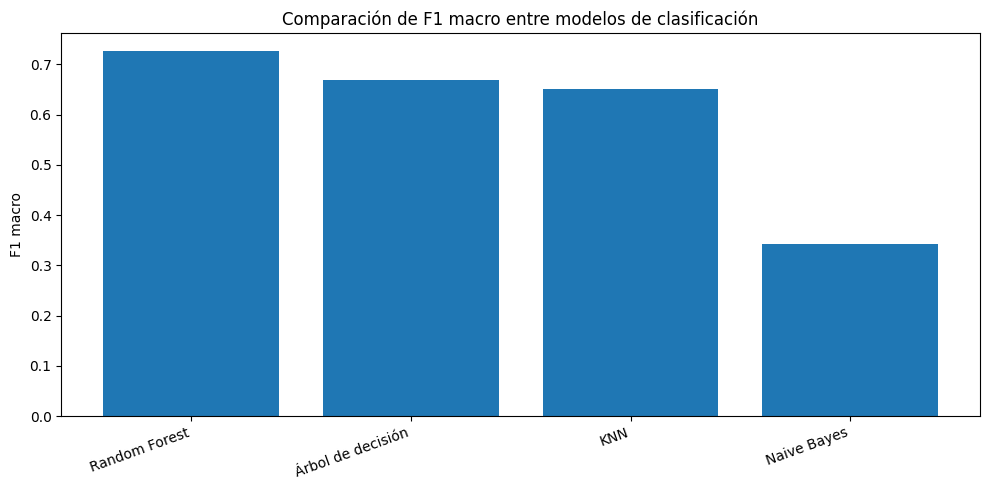

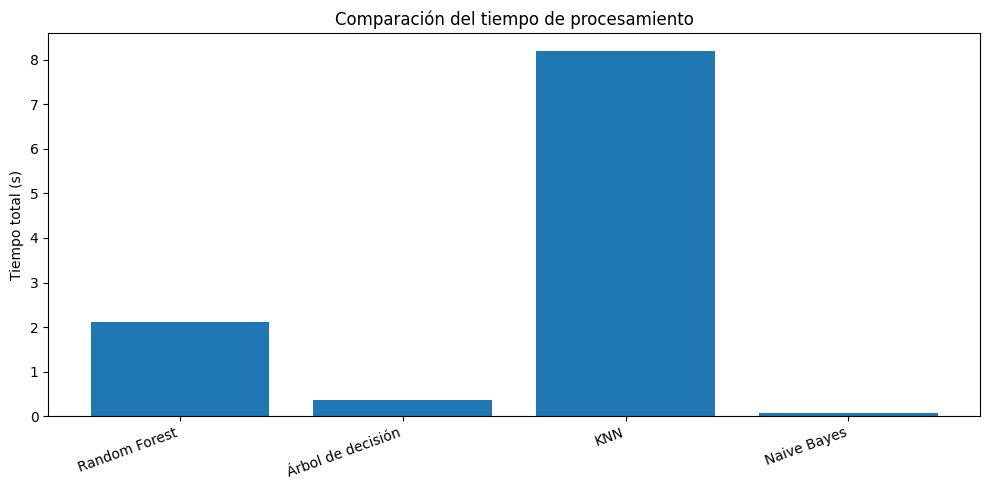

In [23]:
plt.figure(figsize=(10,5))
plt.bar(comparacion_clasificacion["Modelo"], comparacion_clasificacion["F1 macro"])
plt.ylabel("F1 macro")
plt.title("Comparación de F1 macro entre modelos de clasificación")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(comparacion_clasificacion["Modelo"], comparacion_clasificacion["Tiempo total (s)"])
plt.ylabel("Tiempo total (s)")
plt.title("Comparación del tiempo de procesamiento")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()